In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
clean_path = "../../data/cleaned_wells.csv"
link_path = "../../data/link_table.csv"

df = pd.read_csv(clean_path)
link_df = pd.read_csv(link_path)

df.head(), link_df.head()

(   OBJ_ID  Permit number - API            Well Type            Well Status  \
 0   98569         3.408360e+13          Plugged gas  Plugged and Abandoned   
 1  230941         3.420000e+13                  Gas           Well Drilled   
 2   36229         3.402960e+13                  Oil           Well Drilled   
 3  182932         3.412760e+13          Plugged oil  Plugged and Abandoned   
 4  176936         3.412720e+13  Plugged oil and gas      Final Restoration   
 
   Well_GIS_Status      County   Township                Company  \
 0         Drilled        KNOX       PIKE         HISTORIC OWNER   
 1         Drilled  WASHINGTON    NEWPORT  SHELLY MATERIALS INC.   
 2         Drilled  COLUMBIANA  MIDDLETON         HISTORIC OWNER   
 3         Drilled       PERRY       PIKE         HISTORIC OWNER   
 4         Drilled       PERRY    JACKSON         GINGERICH MIKE   
 
                                Well_OP_Address Well_CompanyPHONE  ...  \
 0  2045 Morse Rd., Bldg F-2 COLUMBUS, O

In [4]:
link_df['proximity_risk'] = pd.cut(
    link_df['distance_miles'],
    bins=[0, 1, 3, 5, 10, np.inf],
    labels=[5, 4, 3, 2, 1],
    right=False
).astype(int)
link_df.head()


,injection_OBJ_ID,injection_API,injection_lat,injection_lon,production_OBJ_ID,production_API,production_lat,production_lon,distance_miles,OBJ_ID,prod_change,distance_band,proximity_risk
0,7521,3.400520e+13,40.887283,-82.160396,6813,3.400520e+13,40.825272,-82.202185,4.809024,6813,0.0,3–5,3
1,7521,3.400520e+13,40.887283,-82.160396,9693,3.400560e+13,40.830012,-82.257892,6.451067,9693,0.0,5–10,2
2,7521,3.400520e+13,40.887283,-82.160396,7945,3.400520e+13,40.826010,-82.189310,4.495138,7945,-31.0,3–5,3
3,7521,3.400520e+13,40.887283,-82.160396,6421,3.400520e+13,40.834137,-82.210335,4.504876,6421,0.0,3–5,3
4,7521,3.400520e+13,40.887283,-82.160396,5323,3.400520e+13,40.835461,-82.184676,3.798704,5323,0.0,3–5,3


In [5]:
df['prod_null_reason'] = None

df['Well_Date_Complete'] = pd.to_datetime(df['Well_Date_Complete'], errors='coerce')
df['Well_Date_Approved'] = pd.to_datetime(df['Well_Date_Approved'], errors='coerce')
df['Well_Date_Plugged'] = pd.to_datetime(df['Well_Date_Plugged'], errors='coerce')


# A. Never completed / expired permit
df.loc[
    df['Last_Nonzero_Production_Year'].isna() &
    df['Well_Date_Complete'].isna(),
    'prod_null_reason'
] = 'never_completed'

# B. Non-producing well types
non_prod_types = ['Gas storage', 'Injection', 'Disposal', 'Dry hole', 'Expired permit']
df.loc[
    df['Last_Nonzero_Production_Year'].isna() &
    df['Well Type'].isin(non_prod_types),
    'prod_null_reason'
] = 'non_producing_type'

# C. Completed long ago but missing production records
df.loc[
    df['Last_Nonzero_Production_Year'].isna() &
    df['Well_Date_Complete'].notna(),
    'prod_null_reason'
] = 'missing_historical_prod'

# D. Placeholder dates
df.loc[
    df['Last_Nonzero_Production_Year'].isna() &
    (df['Well_Date_Complete'].dt.year < 1920),
    'prod_null_reason'
] = 'placeholder_dates'

df.head()

,OBJ_ID,Permit number - API,Well Type,Well Status,Well_GIS_Status,County,Township,Company,Well_OP_Address,Well_CompanyPHONE,...,x,y,lat_rad,lon_rad,lat_delta,is_horizontal,years_since_approved,age_category,prod_change,prod_null_reason
0,98569,3.408360e+13,Plugged gas,Plugged and Abandoned,Drilled,KNOX,PIKE,HISTORIC OWNER,"2045 Morse Rd., Bldg F-2 COLUMBUS, OH 43229",6148885080,...,2004624.983,9.104840e+05,0.706851,-1.437630,40.499573,1,NaN,NaN,0.0,missing_historical_prod
1,230941,3.420000e+13,Gas,Well Drilled,Drilled,WASHINGTON,NEWPORT,SHELLY MATERIALS INC.,"1771 HARMON AVENUE COLUMBUS, OH 43223",7402251505,...,2293093.591,4.925308e+05,0.686728,-1.419863,NaN,0,4.0,0–5,0.0,placeholder_dates
2,36229,3.402960e+13,Oil,Well Drilled,Drilled,COLUMBIANA,MIDDLETON,HISTORIC OWNER,"2045 Morse Rd., Bldg F-2 COLUMBUS, OH 43229",6148885080,...,2511867.364,1.020363e+06,0.711832,-1.405657,40.784986,1,NaN,NaN,0.0,missing_historical_prod
3,182932,3.412760e+13,Plugged oil,Plugged and Abandoned,Drilled,PERRY,PIKE,HISTORIC OWNER,"2045 Morse Rd., Bldg F-2 COLUMBUS, OH 43229",6148885080,...,2049612.530,6.288057e+05,0.693351,-1.434863,39.726089,1,NaN,NaN,0.0,missing_historical_prod
4,176936,3.412720e+13,Plugged oil and gas,Final Restoration,Drilled,PERRY,JACKSON,GINGERICH MIKE,"10285 GREER ROAD MCCONNELSVILLE, OH 43756",7409622918,...,2037474.463,6.299376e+05,0.693407,-1.435616,39.729295,1,23.0,21–40,0.0,None


In [6]:
df['years_since_last_prod'] = 2025 - df['Last_Nonzero_Production_Year']

df['recency_risk'] = None
mask = df['Last_Nonzero_Production_Year'].notna()

recency_values = pd.cut(
    df.loc[mask, 'years_since_last_prod'],
    bins=[0, 10, 20, 100],
    labels=[1, 3, 5],
    right=False
)

df.loc[mask, 'recency_risk'] = recency_values.astype(int)




In [7]:
df.loc[df['prod_null_reason'] == 'never_completed', 'recency_risk'] = 5
df.loc[df['prod_null_reason'] == 'non_producing_type', 'recency_risk'] = 0
df.loc[df['prod_null_reason'] == 'missing_historical_prod', 'recency_risk'] = 4
df.loc[df['prod_null_reason'] == 'placeholder_dates', 'recency_risk'] = 5

df['recency_risk'] = df['recency_risk'].astype(int)


In [8]:
df['years_since_approval'] = 2025 - df['Well_Date_Approved'].dt.year
df['years_since_approval'].describe()
df['years_since_approval'].isna().sum()


np.int64(10413)

Given the stats:
Young wells (<20 years) → rare
Mid-age wells (20–40) → medium risk
Old wells (40+) → high risk
Missing approval date → very high risk (due to uncertainty)
25% of wells are 29+ → great boundary
Median = 41 → marks good mid→high cutoff
Upper range goes to 125 → needs a top bin
Missing date ↦ high risk

Approval age is used as a proxy for well construction quality and regulatory rigor.
Wells approved within the last 20 years use modern drilling and casing standards and therefore receive the lowest risk score.
Wells 20–40 years old show increased structural and environmental risk due to aging completions.
Wells 40–60 years old represent legacy infrastructure with significant integrity concerns.
Wells older than 60 years or lacking an approval date entirely receive the highest risk score due to deterioration and uncertainty in documentation.

In [9]:
df['Well_Date_Approved'] = pd.to_datetime(df['Well_Date_Approved'], errors='coerce')
df['approval_risk'] = None

mask = df['years_since_approval'].notna()

df.loc[mask, 'approval_risk'] = pd.cut(
    df.loc[mask, 'years_since_approval'],
    bins=[0, 20, 40, 60, 200],     # 200 = safe cap
    labels=[1, 3, 4, 5],
    right=False
).astype(int)

# Missing approval = Very high risk
df.loc[df['years_since_approval'].isna(), 'approval_risk'] = 5

df['approval_risk'] = df['approval_risk'].astype(int)



In [26]:
# combine the risk scores into one dataset

risk_df = link_df.merge(
    df[['OBJ_ID', 'recency_risk', 'approval_risk', 'Well Type','Last_Nonzero_Production_Year','Well Longitude','Well Latitude']],
    left_on='production_OBJ_ID',
    right_on='OBJ_ID',
    how='left'
)

risk_df.head()

,injection_OBJ_ID,injection_API,injection_lat,injection_lon,production_OBJ_ID,production_API,production_lat,production_lon,distance_miles,OBJ_ID_x,prod_change,distance_band,proximity_risk,OBJ_ID_y,recency_risk,approval_risk,Well Type,Last_Nonzero_Production_Year,Well Longitude,Well Latitude
0,7521,3.400520e+13,40.887283,-82.160396,6813,3.400520e+13,40.825272,-82.202185,4.809024,6813,0.0,3–5,3,6813,5,5,Plugged gas,NaN,-82.202185,40.825272
1,7521,3.400520e+13,40.887283,-82.160396,9693,3.400560e+13,40.830012,-82.257892,6.451067,9693,0.0,5–10,2,9693,5,5,Plugged gas,NaN,-82.257892,40.830012
2,7521,3.400520e+13,40.887283,-82.160396,7945,3.400520e+13,40.826010,-82.189310,4.495138,7945,-31.0,3–5,3,7945,5,1,Plugged oil with gas show,1993.0,-82.189310,40.826010
3,7521,3.400520e+13,40.887283,-82.160396,6421,3.400520e+13,40.834137,-82.210335,4.504876,6421,0.0,3–5,3,6421,0,5,Dry hole,NaN,-82.210335,40.834137
4,7521,3.400520e+13,40.887283,-82.160396,5323,3.400520e+13,40.835461,-82.184676,3.798704,5323,0.0,3–5,3,5323,0,5,Dry hole,NaN,-82.184676,40.835461


In [34]:
# Weighted composite score
risk_df['weighted_risk'] = (
      risk_df['proximity_risk'] * 0.5
    + risk_df['approval_risk']   * 0.3
    + risk_df['recency_risk']    * 0.2
)

# Quantile classification
risk_df['risk_category'] = pd.qcut(
    risk_df['weighted_risk'],
    q=4,
    labels=['Low','Elevated','High','Critical']
)

In [35]:
category_counts = risk_df['risk_category'].value_counts().sort_index()
category_counts


risk_category
Low         3980
Elevated    5758
High        3109
Critical    2680
Name: count, dtype: int64

In [36]:
drivers = risk_df.groupby('risk_category')[
    ['proximity_risk','approval_risk','recency_risk']
].mean().round(2)
drivers


/var/folders/wq/0251_rxs3893xdqcrkc3xwpr0000gn/T/ipykernel_12795/872140229.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  drivers = risk_df.groupby('risk_category')[


,proximity_risk,approval_risk,recency_risk
risk_category,,,
Low,2.32,3.06,1.67
Elevated,2.72,4.37,3.09
High,3.40,4.48,4.23
Critical,4.37,4.74,4.55


for Critical risk wells

In [37]:
# do for each risk_cat
critical = risk_df[risk_df['risk_category']=='Critical']
critical['Well Type'].value_counts().head(10)


Well Type
Oil                               714
Plugged oil                       632
Dry hole                          307
Plugged oil and gas               219
Gas                               163
Oil and gas                       154
Plugged gas                       148
Plugged injection                  73
Dry hole with oil and gas show     39
Plugged oil with gas show          36
Name: count, dtype: int64

In [38]:
#create a risk index that incorporates how risky the well is and if its close to another well

risk_df['priority'] = (
      risk_df['risk_category']
        .replace({'Low':1,'Elevated':2,'High':3,'Critical':4})
        .astype(float)
    * (1 + risk_df['proximity_risk'])
)


top_targets = risk_df.sort_values('priority', ascending=False).head(25)
top_targets


/var/folders/wq/0251_rxs3893xdqcrkc3xwpr0000gn/T/ipykernel_12795/1014007613.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({'Low':1,'Elevated':2,'High':3,'Critical':4})
/var/folders/wq/0251_rxs3893xdqcrkc3xwpr0000gn/T/ipykernel_12795/1014007613.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  .replace({'Low':1,'Elevated':2,'High':3,'Critical':4})


,injection_OBJ_ID,injection_API,injection_lat,injection_lon,production_OBJ_ID,production_API,production_lat,production_lon,distance_miles,OBJ_ID_x,...,recency_risk,approval_risk,Well Type,Last_Nonzero_Production_Year,Well Longitude,Well Latitude,geometry,weighted_risk,risk_category,priority
3743,203878,3.415520e+13,41.309771,-80.613256,204353,3.415520e+13,41.297518,-80.619432,0.905268,204353,...,5,3,Gas with oil show,1990.0,-80.619432,41.297518,POINT (-80.619432 41.297518),4.4,Critical,24.0
3876,6687,3.400520e+13,40.896969,-82.143398,6266,3.400520e+13,40.893308,-82.160223,0.914433,6266,...,1,5,Oil,2023.0,-82.160223,40.893308,POINT (-82.160223 40.893308),4.2,Critical,24.0
15413,7774,3.400520e+13,40.895872,-82.151127,5548,3.400520e+13,40.905043,-82.137696,0.945267,5548,...,4,5,Dry hole,NaN,-82.137696,40.905043,POINT (-82.137696 40.905043),4.8,Critical,24.0
3555,186360,3.413320e+13,41.258874,-81.215694,185055,3.413320e+13,41.263653,-81.213418,0.350723,185055,...,5,4,Plugged oil and gas,NaN,-81.213418,41.263653,POINT (-81.213418 41.263653),4.7,Critical,24.0
3564,186360,3.413320e+13,41.258874,-81.215694,186309,3.413320e+13,41.262774,-81.208524,0.459670,186309,...,4,3,Plugged oil and gas,NaN,-81.208524,41.262774,POINT (-81.208524 41.262774),4.2,Critical,24.0
3910,6687,3.400520e+13,40.896969,-82.143398,6236,3.400520e+13,40.893294,-82.160900,0.948721,6236,...,1,5,Oil,2023.0,-82.160900,40.893294,POINT (-82.1609 40.893294),4.2,Critical,24.0
3913,6687,3.400520e+13,40.896969,-82.143398,10597,3.400560e+13,40.891044,-82.160199,0.968308,10597,...,1,5,Oil and gas,2023.0,-82.160199,40.891044,POINT (-82.160199 40.891044),4.2,Critical,24.0
3915,6687,3.400520e+13,40.896969,-82.143398,10525,3.400560e+13,40.891767,-82.158857,0.883803,10525,...,1,5,Oil,2023.0,-82.158857,40.891767,POINT (-82.158857 40.891767),4.2,Critical,24.0
3916,6687,3.400520e+13,40.896969,-82.143398,6756,3.400520e+13,40.888933,-82.152950,0.746458,6756,...,1,5,Oil,2023.0,-82.152950,40.888933,POINT (-82.15295 40.888933),4.2,Critical,24.0
3917,6687,3.400520e+13,40.896969,-82.143398,6828,3.400520e+13,40.898979,-82.151946,0.467536,6828,...,4,5,Plugged oil,NaN,-82.151946,40.898979,POINT (-82.151946 40.898979),4.8,Critical,24.0


In [39]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = risk_df[['proximity_risk', 'approval_risk', 'recency_risk']]

# Scale the data so all variables contribute equally
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit 4 clusters (you can test 3–6)
kmeans = KMeans(n_clusters=4, random_state=42)
risk_df['cluster'] = kmeans.fit_predict(X_scaled)


In [40]:
cluster_summary = risk_df.groupby('cluster')[
    ['proximity_risk', 'approval_risk', 'recency_risk']
].mean().round(2)

cluster_summary


,proximity_risk,approval_risk,recency_risk
cluster,,,
0,2.41,4.64,4.76
1,3.17,1.88,3.49
2,2.85,4.10,0.70
3,4.41,4.66,4.16


Cluster 3:
Very old wells
Located extremely close to other wells
Haven’t produced in decades
Often poorly documented or former production wells


Cluster 0:
Very old
Inactive for a long time
Not as close to other wells

Cluster 1:
Newer, structurally better
Close to other wells, elevating migration risk
Some production gaps

Cluster 2:
Older wells
But recently active (low recency risk)
Not extremely close to others

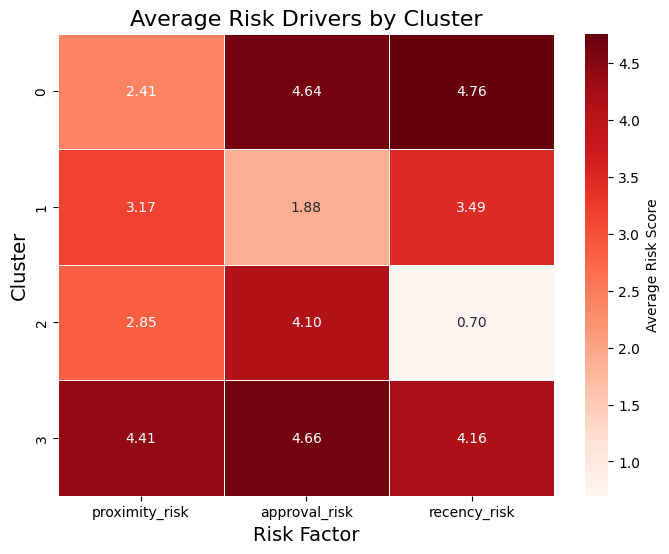

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    cluster_summary,
    annot=True,
    fmt=".2f",
    cmap="Reds",        # color palette
    linewidths=0.5,
    cbar_kws={'label': 'Average Risk Score'}
)

plt.title("Average Risk Drivers by Cluster", fontsize=16)
plt.xlabel("Risk Factor", fontsize=14)
plt.ylabel("Cluster", fontsize=14)
plt.show()


/var/folders/wq/0251_rxs3893xdqcrkc3xwpr0000gn/T/ipykernel_12795/1110040559.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_df.groupby('distance_band')['Last_Nonzero_Production_Year']


<Figure size 1200x600 with 0 Axes>

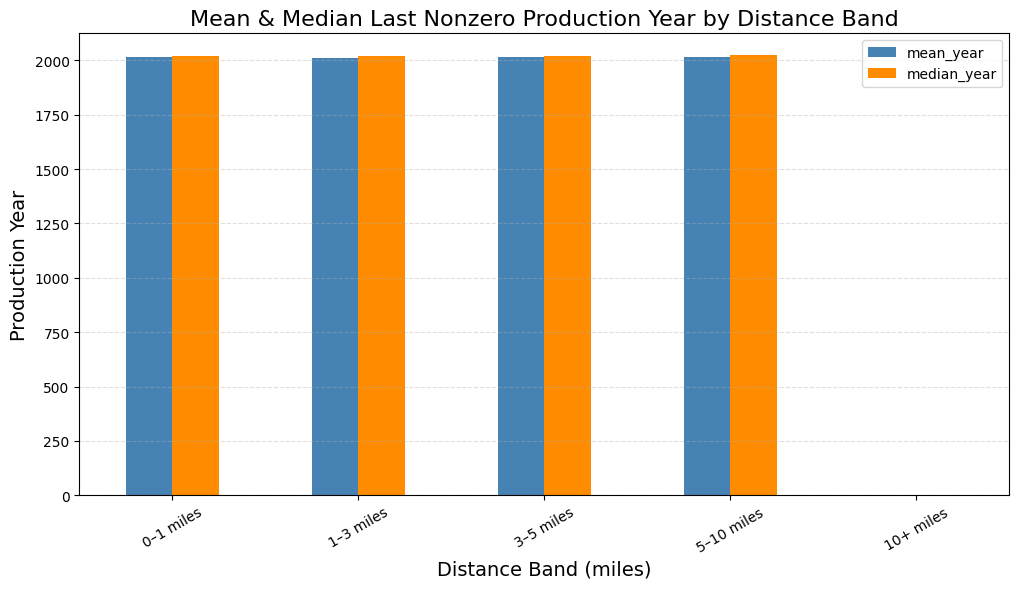

In [19]:
bins = [0, 1, 3, 5, 10, float('inf')]
labels = ['0–1 miles', '1–3 miles', '3–5 miles', '5–10 miles', '10+ miles']

risk_df['distance_band'] = pd.cut(
    risk_df['distance_miles'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

dist_summary = (
    risk_df.groupby('distance_band')['Last_Nonzero_Production_Year']
           .agg(mean_year='mean', median_year='median', count='count')
           .round(2)
)

dist_summary

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

dist_summary[['mean_year','median_year']].plot(
    kind='bar',
    figsize=(12,6),
    rot=30,
    color=['steelblue','darkorange']
)

plt.title("Mean & Median Last Nonzero Production Year by Distance Band", fontsize=16)
plt.xlabel("Distance Band (miles)", fontsize=14)
plt.ylabel("Production Year", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()



In [20]:
print(dist_summary)

               mean_year  median_year  count
distance_band                               
0–1 miles        2013.51       2022.0    478
1–3 miles        2012.71       2020.0   1228
3–5 miles        2013.53       2021.0   2194
5–10 miles       2013.20       2023.0   2559
10+ miles            NaN          NaN      0


In [42]:
import geopandas as gpd
from shapely.geometry import Point

# rename columns if needed
risk_df['geometry'] = risk_df.apply(
    lambda row: Point(row['Well Longitude'], row['Well Latitude']),
    axis=1
)

gdf = gpd.GeoDataFrame(risk_df, geometry='geometry', crs="EPSG:4326")


# Load Ohio boundary
ohio = gpd.read_file("../../data/ohio.geojson")


In [43]:
gdf.columns


Index(['injection_OBJ_ID', 'injection_API', 'injection_lat', 'injection_lon',
       'production_OBJ_ID', 'production_API', 'production_lat',
       'production_lon', 'distance_miles', 'OBJ_ID_x', 'prod_change',
       'distance_band', 'proximity_risk', 'OBJ_ID_y', 'recency_risk',
       'approval_risk', 'Well Type', 'Last_Nonzero_Production_Year',
       'Well Longitude', 'Well Latitude', 'geometry', 'weighted_risk',
       'risk_category', 'priority', 'cluster'],
      dtype='object')

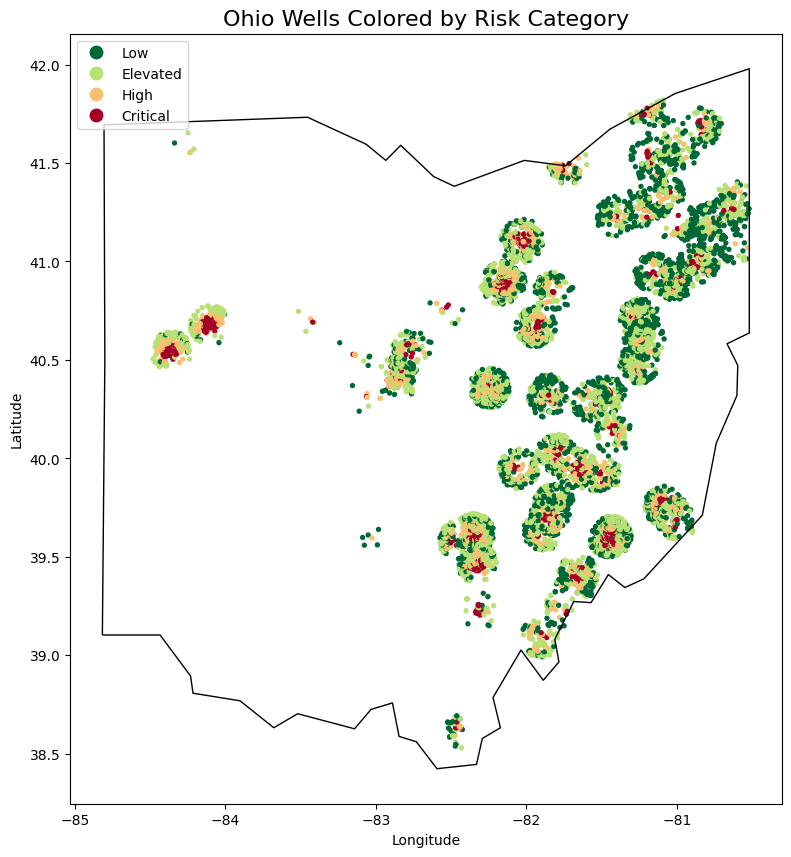

In [44]:
fig, ax = plt.subplots(figsize=(10,10))

# Plot Ohio outline
ohio.boundary.plot(ax=ax, color='black', linewidth=1)

# Plot wells colored by risk category
gdf.plot(
    ax=ax,
    column='risk_category',
    categorical=True,
    legend=True,
    markersize=8,
    cmap="RdYlGn_r"  # green → low, red → high
)

plt.title("Ohio Wells Colored by Risk Category", fontsize=16)
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()
